<a href="https://colab.research.google.com/github/InanyaMadan/Forgery-Detection/blob/main/signature_verification_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Writer Robustness of Structural vs. Statistical Forensic Features
### Signature Forgery Detection — Siamese CNN with Stroke-Junction Attention

This notebook trains and evaluates two variants of the same Siamese architecture:
- **Baseline**: plain Siamese CNN + triplet loss
- **Proposed**: same network + a stroke-junction attention module (skeleton keypoints → CBAM-style spatial attention)

Run cells top to bottom. GPU runtime recommended: `Runtime > Change runtime type > T4 GPU`.


## 1. Setup

In [1]:
!pip install -q scikit-image opencv-python-headless torch torchvision kagglehub
import os, random, math, json, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import cv2
from PIL import Image
from skimage.morphology import skeletonize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


Using device: cuda


## 2. Mount Drive (optional, recommended)
Persists datasets/checkpoints across Colab session resets.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/signature_project/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Mounted at /content/drive


## 3. Load dataset — cedarbhsig-260 (single clean bundle)

This bundle reconstructs all three sets we need — BHSig260-Hindi, BHSig260-Bengali, and CEDAR —
each with explicit `Genuine`/`Forged` subfolders. Cleaner than parsing labels out of a flat
writer-folder layout, so we use this bundle exclusively.

Writer IDs (e.g. `7`, `47`) repeat *across* the three sub-datasets — Hindi writer 7 and CEDAR
writer 7 are different people — so writer IDs get namespaced per sub-dataset (`hindi_7`,
`cedar_7`, etc.) to avoid incorrectly merging them during the writer-independent split.

In [3]:
import kagglehub

cedar_bundle_path = kagglehub.dataset_download('ankita22053139/cedarbhsig-260')
print('Downloaded to:', cedar_bundle_path)


100%|██████████| 292M/292M [00:16<00:00, 18.1MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/ankita22053139/cedarbhsig-260/versions/1


In [4]:
# Locate the three reconstructed sub-dataset roots inside the bundle without hardcoding
# timestamped folder names (those can shift between dataset versions or cache locations).
def find_root(bundle_path, name_fragment):
    matches = glob.glob(os.path.join(bundle_path, '**', name_fragment), recursive=True)
    matches = [m for m in matches if os.path.isdir(m)]
    if not matches:
        raise FileNotFoundError(f'No folder matching {name_fragment!r} found under {bundle_path}')
    return sorted(matches, key=len)[-1]  # prefer the innermost duplicated folder

bhsig_hindi_root = find_root(cedar_bundle_path, 'Reconstructed_BHSig160')
bhsig_bengali_root = find_root(cedar_bundle_path, 'Reconstructed_BHSig100')
cedar_root = find_root(cedar_bundle_path, 'Reconstructed_CEDAR')

print('Hindi root:  ', bhsig_hindi_root)
print('Bengali root:', bhsig_bengali_root)
print('CEDAR root:  ', cedar_root)


Hindi root:   /root/.cache/kagglehub/datasets/ankita22053139/cedarbhsig-260/versions/1/Reconstructed_BHSig160-20250403T183033Z-001/Reconstructed_BHSig160
Bengali root: /root/.cache/kagglehub/datasets/ankita22053139/cedarbhsig-260/versions/1/Reconstructed_BHSig100-20250403T193101Z-001/Reconstructed_BHSig100
CEDAR root:   /root/.cache/kagglehub/datasets/ankita22053139/cedarbhsig-260/versions/1/Reconstructed_CEDAR/Reconstructed_CEDAR


In [5]:
# Quick count check against known spec before trusting the data:
# BHSig260-Hindi: 160 writers, 24 genuine + 30 forged each -> 3840 genuine, 4800 forged
# BHSig260-Bengali: 100 writers, 24 genuine + 30 forged each -> 2400 genuine, 3000 forged
# CEDAR: 55 writers, 24 genuine + 24 forged each -> 1320 genuine, 1320 forged
for name, root in [('Hindi', bhsig_hindi_root), ('Bengali', bhsig_bengali_root), ('CEDAR', cedar_root)]:
    n_genuine = len(glob.glob(os.path.join(root, 'Genuine', '*')))
    n_forged = len(glob.glob(os.path.join(root, 'Forged', '*')))
    print(f'{name}: {n_genuine} genuine, {n_forged} forged')


Hindi: 3840 genuine, 4800 forged
Bengali: 2400 genuine, 3000 forged
CEDAR: 1320 genuine, 1320 forged


In [6]:
import re

def parse_bhsig_filename(fname):
    # e.g. H-S-70-G-08.tif or B-S-83-G-24.tif -> writer=70, label=genuine
    m = re.match(r'[HB]-S-(\d+)-([GF])-\d+\.tif', fname)
    if not m:
        return None
    writer_id, label_code = m.group(1), m.group(2)
    return writer_id, ('genuine' if label_code == 'G' else 'forged')

def parse_cedar_filename(fname):
    # e.g. original_7_9.png or forgeries_7_20.png -> writer=7, label
    m = re.match(r'(original|forgeries)_(\d+)_\d+\.png', fname)
    if not m:
        return None
    kind, writer_id = m.group(1), m.group(2)
    return writer_id, ('genuine' if kind == 'original' else 'forged')

def build_sample_list(base_dir, dataset_tag, parse_fn):
    '''''''''dataset_tag namespaces writer IDs (e.g. 'hindi_7', 'cedar_7') so the same numeric
    writer ID across datasets is never treated as one person.'''''''''
    samples = []
    for label_dir, expected_label in [('Genuine', 'genuine'), ('Forged', 'forged')]:
        folder = os.path.join(base_dir, label_dir)
        for fpath in glob.glob(os.path.join(folder, '*')):
            fname = os.path.basename(fpath)
            parsed = parse_fn(fname)
            if parsed is None:
                continue  # skip anything that doesn't match the expected filename pattern
            writer_id, label = parsed
            assert label == expected_label, f'Label mismatch in {fname}: folder says {expected_label}, filename says {label}'
            samples.append({
                'image': Image.open(fpath),
                'writer_id': f'{dataset_tag}_{writer_id}',
                'label': label,
            })
    return samples

hindi_samples = build_sample_list(bhsig_hindi_root, 'hindi', parse_bhsig_filename)
bengali_samples = build_sample_list(bhsig_bengali_root, 'bengali', parse_bhsig_filename)
cedar_samples = build_sample_list(cedar_root, 'cedar', parse_cedar_filename)

bhsig_samples = hindi_samples + bengali_samples  # combined BHSig260 pool

print(f'Hindi: {len(set(s["writer_id"] for s in hindi_samples))} writers, {len(hindi_samples)} samples')
print(f'Bengali: {len(set(s["writer_id"] for s in bengali_samples))} writers, {len(bengali_samples)} samples')
print(f'CEDAR: {len(set(s["writer_id"] for s in cedar_samples))} writers, {len(cedar_samples)} samples')


Hindi: 160 writers, 8640 samples
Bengali: 100 writers, 5400 samples
CEDAR: 55 writers, 2640 samples


## 4. Preprocessing pipeline

Grayscale → normalize → resize → binarize. Binarization is only required for the skeletonization
branch (proposed variant) — the baseline CNN uses the grayscale/resized image directly.

In [7]:
IMG_SIZE = 224

def to_grayscale_np(pil_img):
    return np.array(pil_img.convert('L'))

def resize_np(img, size=IMG_SIZE):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def normalize_np(img):
    img = img.astype(np.float32)
    return (img - img.mean()) / (img.std() + 1e-6)

def binarize_np(img_gray_uint8):
    # Otsu thresholding on the resized grayscale (pre-normalization) image.
    _, binary = cv2.threshold(img_gray_uint8, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return (binary > 0).astype(np.uint8)  # foreground strokes = 1

def preprocess(pil_img, size=IMG_SIZE):
    gray = to_grayscale_np(pil_img)
    gray_resized = resize_np(gray, size)
    binary = binarize_np(gray_resized)
    normalized = normalize_np(gray_resized)
    return normalized, binary  # (float array input, binary mask for skeleton branch)


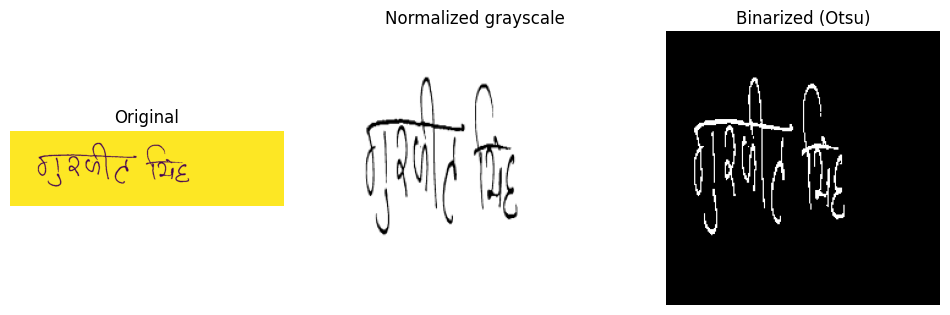

In [8]:
# Visual sanity check — always look at a few outputs before trusting the pipeline.
sample = bhsig_samples[0]  # swap index or use cedar_samples[0] to check other sub-datasets

norm_img, bin_img = preprocess(sample['image'])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.array(sample['image']))
axes[0].set_title('Original')
axes[1].imshow(norm_img, cmap='gray')
axes[1].set_title('Normalized grayscale')
axes[2].imshow(bin_img, cmap='gray')
axes[2].set_title('Binarized (Otsu)')
for ax in axes: ax.axis('off')
plt.show()


## 5. Skeletonization + junction/endpoint detection

Zhang-Suen thinning (via `skimage.morphology.skeletonize`) reduces strokes to 1-pixel width.
Junctions = skeleton pixels with ≥3 neighbours; endpoints = exactly 1 neighbour.
A small spur-pruning pass removes short spurious branches from thinning noise —
this directly addresses the fragility flagged in the Review 1 document.

In [9]:
def get_skeleton(binary_mask):
    return skeletonize(binary_mask.astype(bool)).astype(np.uint8)

def neighbor_count_map(skeleton):
    kernel = np.array([[1,1,1],[1,0,1],[1,1,1]], dtype=np.uint8)
    return cv2.filter2D(skeleton, -1, kernel, borderType=cv2.BORDER_CONSTANT)

def prune_spurs(skeleton, min_branch_len=4):
    # Iteratively remove endpoint pixels that belong to very short branches (thinning noise).
    skel = skeleton.copy()
    for _ in range(min_branch_len):
        neighbors = neighbor_count_map(skel)
        endpoints = (skel == 1) & (neighbors == 1)
        if not endpoints.any():
            break
        skel[endpoints] = 0
    return skel

def detect_keypoints(binary_mask, prune=True):
    skel = get_skeleton(binary_mask)
    if prune:
        skel = prune_spurs(skel)
    neighbors = neighbor_count_map(skel)
    junctions = (skel == 1) & (neighbors >= 3)
    endpoints = (skel == 1) & (neighbors == 1)
    keypoint_map = np.zeros_like(skel, dtype=np.float32)
    keypoint_map[junctions] = 1.0
    keypoint_map[endpoints] = 0.5  # weight endpoints lower than junctions
    return keypoint_map, skel


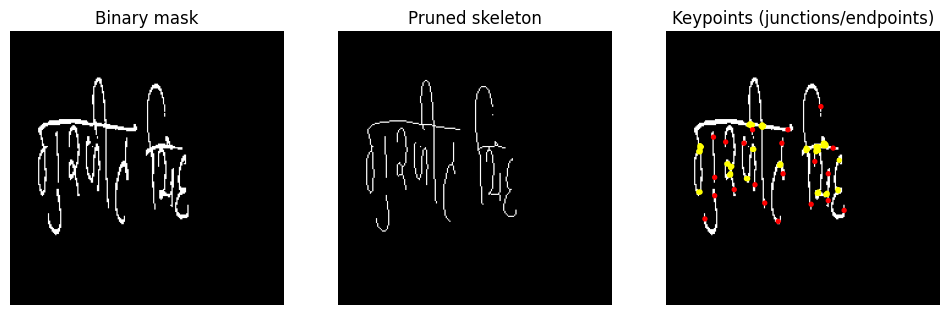

In [10]:
# Visual check: keypoints should sit on real stroke crossings/ends, not scattered thinning noise.
keypoint_map, skel = detect_keypoints(bin_img)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(bin_img, cmap='gray'); axes[0].set_title('Binary mask')
axes[1].imshow(skel, cmap='gray'); axes[1].set_title('Pruned skeleton')
axes[2].imshow(bin_img, cmap='gray')
ys, xs = np.where(keypoint_map > 0)
axes[2].scatter(xs, ys, c=keypoint_map[ys, xs], cmap='autumn', s=8)
axes[2].set_title('Keypoints (junctions/endpoints)')
for ax in axes: ax.axis('off')
plt.show()


## 6. Dataset class — builds genuine/forged triplets per writer

In [11]:
class SignaturePairDataset(Dataset):
    '''''''''
    Expects `samples`: list of dicts {'image': PIL.Image, 'writer_id': str, 'label': 'genuine'/'forged'}.
    Builds (anchor, positive, negative) triplets: anchor/positive = same writer genuine,
    negative = either a forged sample of that writer or a genuine sample from a different writer.
    '''''''''
    def __init__(self, samples, img_size=IMG_SIZE, with_skeleton=False):
        self.samples = samples
        self.img_size = img_size
        self.with_skeleton = with_skeleton
        self.by_writer_genuine = {}
        self.by_writer_forged = {}
        for i, s in enumerate(samples):
            bucket = self.by_writer_genuine if s['label'] == 'genuine' else self.by_writer_forged
            bucket.setdefault(s['writer_id'], []).append(i)
        self.writers = [w for w, idxs in self.by_writer_genuine.items() if len(idxs) >= 2]

    def __len__(self):
        return len(self.writers) * 4  # a few triplets sampled per writer per epoch

    def _load(self, idx):
        pil_img = self.samples[idx]['image']
        norm_img, binary = preprocess(pil_img, self.img_size)
        tensor = torch.from_numpy(norm_img).unsqueeze(0).float()  # (1, H, W)
        if self.with_skeleton:
            kp_map, _ = detect_keypoints(binary)
            kp_tensor = torch.from_numpy(kp_map).unsqueeze(0).float()
            return tensor, kp_tensor
        return tensor, None

    def __getitem__(self, idx):
        writer = self.writers[idx % len(self.writers)]
        genuine_idxs = self.by_writer_genuine[writer]
        a_idx, p_idx = random.sample(genuine_idxs, 2)

        forged_idxs = self.by_writer_forged.get(writer, [])
        if forged_idxs and random.random() < 0.5:
            n_idx = random.choice(forged_idxs)
        else:
            other_writer = random.choice([w for w in self.writers if w != writer])
            n_idx = random.choice(self.by_writer_genuine[other_writer])

        a_img, a_kp = self._load(a_idx)
        p_img, p_kp = self._load(p_idx)
        n_img, n_kp = self._load(n_idx)

        if self.with_skeleton:
            return (a_img, a_kp), (p_img, p_kp), (n_img, n_kp)
        return a_img, p_img, n_img


## 7. Backbone, embedding head, and the two variants

Both variants share the exact same backbone, embedding head, and loss — the only difference
is whether `AttentionFusion` is inserted before pooling. This isolation is what makes the
baseline-vs-proposed comparison a clean ablation.

In [12]:
class Backbone(nn.Module):
    def __init__(self, arch='resnet18', pretrained=True):
        super().__init__()
        if arch == 'resnet18':
            net = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
            net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # single-channel input
            self.features = nn.Sequential(*list(net.children())[:-2])  # up to last conv feature map
            self.out_channels = 512
        else:
            raise ValueError('Add EfficientNet-B0 branch here for the backbone ablation.')

    def forward(self, x):
        return self.features(x)  # (B, C, H', W')


class AttentionFusion(nn.Module):
    '''''''''CBAM-style sequential attention: channel attention stays feature-derived,
    spatial attention is junction-keypoint-derived (this is the project's core novelty).'''''''''
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels)
        )
        self.spatial_conv = nn.Conv2d(1, 1, kernel_size=7, padding=3)  # keypoint map -> spatial attention

    def forward(self, feat_map, keypoint_map):
        # Channel attention (feature-derived, as in standard CBAM)
        avg_pool = feat_map.mean(dim=[2, 3])
        max_pool = feat_map.amax(dim=[2, 3])
        channel_att = torch.sigmoid(self.channel_mlp(avg_pool) + self.channel_mlp(max_pool))
        feat_map = feat_map * channel_att.unsqueeze(-1).unsqueeze(-1)

        # Spatial attention (junction-derived, not feature-derived)
        kp_resized = F.interpolate(keypoint_map, size=feat_map.shape[2:], mode='bilinear', align_corners=False)
        spatial_att = torch.sigmoid(self.spatial_conv(kp_resized))
        feat_map = feat_map * spatial_att
        return feat_map


class EmbeddingHead(nn.Module):
    def __init__(self, in_channels, embed_dim=128):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(in_channels, embed_dim)

    def forward(self, feat_map):
        pooled = self.pool(feat_map).flatten(1)
        embedding = F.normalize(self.fc(pooled), p=2, dim=1)
        return embedding


class SiameseNet(nn.Module):
    '''''''''variant='baseline' or 'proposed'. Same backbone/head either way.'''''''''
    def __init__(self, variant='baseline', arch='resnet18', embed_dim=128):
        super().__init__()
        self.variant = variant
        self.backbone = Backbone(arch)
        self.head = EmbeddingHead(self.backbone.out_channels, embed_dim)
        if variant == 'proposed':
            self.attention = AttentionFusion(self.backbone.out_channels)

    def forward(self, img, keypoint_map=None):
        feat_map = self.backbone(img)
        if self.variant == 'proposed':
            assert keypoint_map is not None, 'proposed variant requires a keypoint map'
            feat_map = self.attention(feat_map, keypoint_map)
        return self.head(feat_map)


## 8. Training loop (shared by both variants)

In [13]:
def train_one_variant(variant, train_dataset, val_dataset, epochs=15, batch_size=32, lr=1e-4, margin=0.5):
    model = SiameseNet(variant=variant).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    triplet_loss = nn.TripletMarginLoss(margin=margin, p=2)

    with_skel = (variant.startswith('proposed'))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()
            if with_skel:
                (a_img, a_kp), (p_img, p_kp), (n_img, n_kp) = batch
                a_img, p_img, n_img = a_img.to(device), p_img.to(device), n_img.to(device)
                a_kp, p_kp, n_kp = a_kp.to(device), p_kp.to(device), n_kp.to(device)
                a_emb = model(a_img, a_kp)
                p_emb = model(p_img, p_kp)
                n_emb = model(n_img, n_kp)
            else:
                a_img, p_img, n_img = [x.to(device) for x in batch]
                a_emb, p_emb, n_emb = model(a_img), model(p_img), model(n_img)
            loss = triplet_loss(a_emb, p_emb, n_emb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                if with_skel:
                    (a_img, a_kp), (p_img, p_kp), (n_img, n_kp) = batch
                    a_img, p_img, n_img = a_img.to(device), p_img.to(device), n_img.to(device)
                    a_kp, p_kp, n_kp = a_kp.to(device), p_kp.to(device), n_kp.to(device)
                    a_emb, p_emb, n_emb = model(a_img, a_kp), model(p_img, p_kp), model(n_img, n_kp)
                else:
                    a_img, p_img, n_img = [x.to(device) for x in batch]
                    a_emb, p_emb, n_emb = model(a_img), model(p_img), model(n_img)
                val_loss += triplet_loss(a_emb, p_emb, n_emb).item()
        avg_val = val_loss / len(val_loader)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        print(f'[{variant}] epoch {epoch+1}/{epochs}  train_loss={avg_train:.4f}  val_loss={avg_val:.4f}')

        torch.save(model.state_dict(), f'{CHECKPOINT_DIR}/{variant}_epoch{epoch+1}.pt')

    return model, history


## 9. Writer-independent train/val split (BHSig260)

CEDAR (`cedar_samples`) stays fully held out here — it's used only in Section 12 for
cross-dataset evaluation, never for training or validating the BHSig260-trained models.

In [14]:
def writer_split(samples, train_frac=0.8):
    writers = sorted(set(s['writer_id'] for s in samples))
    random.shuffle(writers)
    split_idx = int(train_frac * len(writers))
    train_writers, val_writers = set(writers[:split_idx]), set(writers[split_idx:])
    train = [s for s in samples if s['writer_id'] in train_writers]
    val = [s for s in samples if s['writer_id'] in val_writers]
    return train, val

train_samples, val_samples = writer_split(bhsig_samples)
print(f'BHSig260: {len(set(s["writer_id"] for s in bhsig_samples))} writers total, '
      f'{len(train_samples)} train samples, {len(val_samples)} val samples')
print(f'CEDAR held out: {len(set(s["writer_id"] for s in cedar_samples))} writers, '
      f'{len(cedar_samples)} samples')


BHSig260: 260 writers total, 11232 train samples, 2808 val samples
CEDAR held out: 55 writers, 2640 samples


## 10. Train both variants (on BHSig260)

In [16]:
train_ds_baseline = SignaturePairDataset(train_samples, with_skeleton=False)
val_ds_baseline = SignaturePairDataset(val_samples, with_skeleton=False)
baseline_model, baseline_history = train_one_variant('baseline', train_ds_baseline, val_ds_baseline)


[baseline] epoch 1/15  train_loss=0.2394  val_loss=0.1326
[baseline] epoch 2/15  train_loss=0.1082  val_loss=0.1280
[baseline] epoch 3/15  train_loss=0.0777  val_loss=0.0840
[baseline] epoch 4/15  train_loss=0.0598  val_loss=0.1143
[baseline] epoch 5/15  train_loss=0.0589  val_loss=0.1085
[baseline] epoch 6/15  train_loss=0.0578  val_loss=0.1171
[baseline] epoch 7/15  train_loss=0.0498  val_loss=0.0983
[baseline] epoch 8/15  train_loss=0.0403  val_loss=0.1037
[baseline] epoch 9/15  train_loss=0.0370  val_loss=0.1121
[baseline] epoch 10/15  train_loss=0.0395  val_loss=0.0908
[baseline] epoch 11/15  train_loss=0.0358  val_loss=0.0914
[baseline] epoch 12/15  train_loss=0.0208  val_loss=0.0810
[baseline] epoch 13/15  train_loss=0.0234  val_loss=0.0763
[baseline] epoch 14/15  train_loss=0.0259  val_loss=0.0810
[baseline] epoch 15/15  train_loss=0.0196  val_loss=0.0950


In [17]:
train_ds_proposed = SignaturePairDataset(train_samples, with_skeleton=True)
val_ds_proposed = SignaturePairDataset(val_samples, with_skeleton=True)
proposed_model, proposed_history = train_one_variant('proposed', train_ds_proposed, val_ds_proposed)


[proposed] epoch 1/15  train_loss=0.2272  val_loss=0.1467
[proposed] epoch 2/15  train_loss=0.1134  val_loss=0.1159
[proposed] epoch 3/15  train_loss=0.0851  val_loss=0.1041
[proposed] epoch 4/15  train_loss=0.0714  val_loss=0.1167
[proposed] epoch 5/15  train_loss=0.0712  val_loss=0.0976
[proposed] epoch 6/15  train_loss=0.0495  val_loss=0.0736
[proposed] epoch 7/15  train_loss=0.0434  val_loss=0.0779
[proposed] epoch 8/15  train_loss=0.0356  val_loss=0.0813
[proposed] epoch 9/15  train_loss=0.0403  val_loss=0.0735
[proposed] epoch 10/15  train_loss=0.0316  val_loss=0.0663
[proposed] epoch 11/15  train_loss=0.0353  val_loss=0.0926
[proposed] epoch 12/15  train_loss=0.0258  val_loss=0.0857
[proposed] epoch 13/15  train_loss=0.0291  val_loss=0.0827
[proposed] epoch 14/15  train_loss=0.0258  val_loss=0.0566
[proposed] epoch 15/15  train_loss=0.0201  val_loss=0.0752


## 11. Evaluation — EER, AUC, Bhattacharyya distance

Computed on genuine-vs-genuine (same writer) distances vs. genuine-vs-forged/other-writer
distances. Same computation applies to both variants and to cross-dataset test sets —
just swap in a different `samples` argument.

In [18]:
def compute_eer(genuine_scores, impostor_scores):
    labels = np.concatenate([np.ones_like(genuine_scores), np.zeros_like(impostor_scores)])
    scores = np.concatenate([genuine_scores, impostor_scores])  # higher score = more similar
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    roc_auc = auc(fpr, tpr)
    return eer, roc_auc

def bhattacharyya_distance(a, b):
    mu1, mu2 = a.mean(), b.mean()
    var1, var2 = a.var(), b.var()
    term1 = 0.25 * np.log(0.25 * (var1/var2 + var2/var1 + 2))
    term2 = 0.25 * ((mu1 - mu2)**2 / (var1 + var2))
    return term1 + term2

@torch.no_grad()
def evaluate_variant(model, samples, with_skeleton, n_pairs=500):
    model.eval()
    ds = SignaturePairDataset(samples, with_skeleton=with_skeleton)
    genuine_dists, impostor_dists = [], []
    for i in range(min(n_pairs, len(ds))):
        item = ds[i]
        if with_skeleton:
            (a_img, a_kp), (p_img, p_kp), (n_img, n_kp) = item
            a_emb = model(a_img.unsqueeze(0).to(device), a_kp.unsqueeze(0).to(device))
            p_emb = model(p_img.unsqueeze(0).to(device), p_kp.unsqueeze(0).to(device))
            n_emb = model(n_img.unsqueeze(0).to(device), n_kp.unsqueeze(0).to(device))
        else:
            a_img, p_img, n_img = item
            a_emb = model(a_img.unsqueeze(0).to(device))
            p_emb = model(p_img.unsqueeze(0).to(device))
            n_emb = model(n_img.unsqueeze(0).to(device))
        genuine_dists.append(F.pairwise_distance(a_emb, p_emb).item())
        impostor_dists.append(F.pairwise_distance(a_emb, n_emb).item())

    genuine_scores = -np.array(genuine_dists)   # convert distance -> similarity score
    impostor_scores = -np.array(impostor_dists)
    eer, roc_auc = compute_eer(genuine_scores, impostor_scores)
    bhat = bhattacharyya_distance(np.array(genuine_dists), np.array(impostor_dists))
    return {'EER': eer, 'AUC': roc_auc, 'Bhattacharyya': bhat}

baseline_metrics = evaluate_variant(baseline_model, val_samples, with_skeleton=False)
proposed_metrics = evaluate_variant(proposed_model, val_samples, with_skeleton=True)
print('Same-dataset (BHSig260) results:')
print('  Baseline :', baseline_metrics)
print('  Proposed :', proposed_metrics)


Same-dataset (BHSig260) results:
  Baseline : {'EER': np.float64(0.08653846153846156), 'AUC': np.float64(0.9583025147928995), 'Bhattacharyya': np.float64(0.8169422915338257)}
  Proposed : {'EER': np.float64(0.1105769230769231), 'AUC': np.float64(0.9564996301775147), 'Bhattacharyya': np.float64(0.7965053379237419)}


## 12. Cross-dataset evaluation

Direction 1 (using the models already trained above): trained on BHSig260, tested on
fully-held-out CEDAR. Direction 2: train fresh copies on CEDAR, test on fully-held-out
BHSig260 — the reverse direction, giving two independent cross-dataset data points.

In [19]:
# Direction 1: BHSig260-trained models -> CEDAR (never seen during training)
cross_baseline_metrics_d1 = evaluate_variant(baseline_model, cedar_samples, with_skeleton=False)
cross_proposed_metrics_d1 = evaluate_variant(proposed_model, cedar_samples, with_skeleton=True)
print('Direction 1 (train BHSig260 -> test CEDAR)')
print('  Baseline:', cross_baseline_metrics_d1)
print('  Proposed:', cross_proposed_metrics_d1)


Direction 1 (train BHSig260 -> test CEDAR)
  Baseline: {'EER': np.float64(0.16590909090909092), 'AUC': np.float64(0.9102272727272728), 'Bhattacharyya': np.float64(0.4566368033754366)}
  Proposed: {'EER': np.float64(0.1818181818181818), 'AUC': np.float64(0.905681818181818), 'Bhattacharyya': np.float64(0.46491180738495946)}


In [23]:
# Direction 2: train fresh on CEDAR, test on fully-held-out BHSig260
cedar_train_samples, cedar_val_samples = writer_split(cedar_samples)

cedar_train_ds_baseline = SignaturePairDataset(cedar_train_samples, with_skeleton=False)
cedar_val_ds_baseline = SignaturePairDataset(cedar_val_samples, with_skeleton=False)
baseline_model_cedar, _ = train_one_variant('baseline_cedar', cedar_train_ds_baseline, cedar_val_ds_baseline)

cedar_train_ds_proposed = SignaturePairDataset(cedar_train_samples, with_skeleton=True)
cedar_val_ds_proposed = SignaturePairDataset(cedar_val_samples, with_skeleton=True)
proposed_model_cedar, _ = train_one_variant('proposed_cedar', cedar_train_ds_proposed, cedar_val_ds_proposed)

cross_baseline_metrics_d2 = evaluate_variant(baseline_model_cedar, bhsig_samples, with_skeleton=False)
cross_proposed_metrics_d2 = evaluate_variant(proposed_model_cedar, bhsig_samples, with_skeleton=True)
print('Direction 2 (train CEDAR -> test BHSig260)')
print('  Baseline:', cross_baseline_metrics_d2)
print('  Proposed:', cross_proposed_metrics_d2)


OSError: Caught OSError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/PIL/ImageFile.py", line 370, in load
    s = read(read_bytes)
  File "/usr/local/lib/python3.13/dist-packages/PIL/PngImagePlugin.py", line 994, in load_read
    cid, pos, length = self.png.read()
                       ~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/PIL/PngImagePlugin.py", line 176, in read
    length = i32(s)
  File "/usr/local/lib/python3.13/dist-packages/PIL/_binary.py", line 95, in i32be
    return unpack_from(">I", c, o)[0]
           ~~~~~~~~~~~^^^^^^^^^^^^
struct.error: unpack_from requires a buffer of at least 4 bytes for unpacking 4 bytes at offset 0 (actual buffer size is 0)

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = 

## 13. Grad-CAM — confirm the attention model anchors on junctions

Generates a heatmap over the input signature showing which regions drove the embedding,
for both variants on the same pair — the visual check for whether the attention module
is actually doing what it claims.

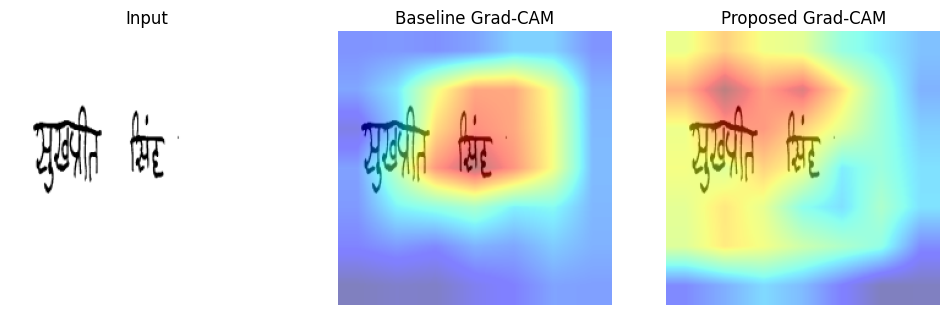

In [24]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer = model.backbone.features[-1]
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, img, keypoint_map=None):
        self.model.eval()
        img = img.unsqueeze(0).to(device).requires_grad_(True)
        kp = keypoint_map.unsqueeze(0).to(device) if keypoint_map is not None else None
        embedding = self.model(img, kp) if kp is not None else self.model(img)
        score = embedding.norm()
        self.model.zero_grad()
        score.backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1)).squeeze().cpu().numpy()
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def show_gradcam_comparison(sample_pair_img, sample_pair_kp=None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(sample_pair_img.squeeze().numpy(), cmap='gray')
    axes[0].set_title('Input')

    cam_baseline = GradCAM(baseline_model).generate(sample_pair_img)
    axes[1].imshow(sample_pair_img.squeeze().numpy(), cmap='gray')
    axes[1].imshow(cam_baseline, cmap='jet', alpha=0.5)
    axes[1].set_title('Baseline Grad-CAM')

    if sample_pair_kp is not None:
        cam_proposed = GradCAM(proposed_model).generate(sample_pair_img, sample_pair_kp)
        axes[2].imshow(sample_pair_img.squeeze().numpy(), cmap='gray')
        axes[2].imshow(cam_proposed, cmap='jet', alpha=0.5)
        axes[2].set_title('Proposed Grad-CAM')

    for ax in axes: ax.axis('off')
    plt.show()

# Example usage on one validation sample:
example_ds = SignaturePairDataset(val_samples, with_skeleton=True)
(a_img, a_kp), _, _ = example_ds[0]
show_gradcam_comparison(a_img, a_kp)
